# 05 — XGBRanker with Walk-Forward Cross-Validation

**Changes vs original:**

- Replaced the single train/valid/test split with **expanding-window walk-forward CV**.
  Each fold trains on all data up to the fold start, then tests on the next 6 months.
  The model is re-trained from scratch every fold.
- A **1-month gap** is inserted between training end and test start to prevent any
  leakage from the lagged monthly return construction at the boundary.
- IC and long-short returns are accumulated across all test folds and evaluated together,
  giving a valid out-of-sample estimate across all available test periods.

**Fold structure (60 months total, 2017-01 to 2021-12):**

| Fold | Train through | Gap | Test period |
|------|--------------|-----|-------------|
| 0    | 2019-12      | 1m  | 2020-02 → 2020-07 |
| 1    | 2020-06      | 1m  | 2020-08 → 2021-01 |
| 2    | 2020-12      | 1m  | 2021-02 → 2021-07 |
| 3    | 2021-06      | 1m  | 2021-08 → 2021-12 |

In [166]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta
from scipy.stats import spearmanr
from xgboost import XGBRanker


## 1. Load data

In [167]:
monthly = pd.read_csv(
    r"C:\Users\naksh\Projects\xgboost_stock_ranking\data\model_data.csv",
    parse_dates=["Date"]
)

with open(r"C:\Users\naksh\Projects\xgboost_stock_ranking\data\processed\feature_cols.json") as f:
    feature_cols = json.load(f)

monthly = monthly.sort_values(["Date", "SecuritiesCode"]).reset_index(drop=True)

print("Shape:", monthly.shape, "  Features:", len(feature_cols))
print("Date range:", monthly["Date"].min().date(), "→", monthly["Date"].max().date())

Shape: (114554, 90)   Features: 79
Date range: 2017-01-31 → 2021-11-30


## 2. Ordinal rank target (32 buckets per month)

In [168]:
monthly["rank_target"] = (
    monthly.groupby("Date")["target_1m"]
    .transform(
        lambda x: pd.qcut(x.rank(method="first"), q=32, labels=False)
    )
    .astype(int)
)

## 3. Walk-forward fold definitions

In [169]:
# Minimum training window before the first fold
MIN_TRAIN_MONTHS = 36
# Number of months in each test fold
TEST_FOLD_MONTHS = 6
# Gap between training end and test start (months)
GAP_MONTHS = 1

all_months = sorted(monthly["Date"].dt.to_period("M").unique())

folds = []
fold_start_idx = MIN_TRAIN_MONTHS  # first test fold starts after MIN_TRAIN_MONTHS

while fold_start_idx + GAP_MONTHS < len(all_months):
    train_end_period = all_months[fold_start_idx - 1]          # last training month
    test_start_period = all_months[fold_start_idx + GAP_MONTHS]  # after gap
    test_end_idx = min(fold_start_idx + GAP_MONTHS + TEST_FOLD_MONTHS - 1, len(all_months) - 1)
    test_end_period = all_months[test_end_idx]

    folds.append({
        "train_end":   train_end_period.to_timestamp(how="end"),
        "test_start":  test_start_period.to_timestamp(how="start"),
        "test_end":    test_end_period.to_timestamp(how="end"),
    })

    fold_start_idx += TEST_FOLD_MONTHS  # advance by one test fold

print(f"{len(folds)} folds:")
for i, f in enumerate(folds):
    print(f"  Fold {i}: train ≤ {f['train_end'].date()}  |  "
          f"test {f['test_start'].date()} → {f['test_end'].date()}")

4 folds:
  Fold 0: train ≤ 2019-12-31  |  test 2020-02-01 → 2020-07-31
  Fold 1: train ≤ 2020-06-30  |  test 2020-08-01 → 2021-01-31
  Fold 2: train ≤ 2020-12-31  |  test 2021-02-01 → 2021-07-31
  Fold 3: train ≤ 2021-06-30  |  test 2021-08-01 → 2021-11-30


## 4. Walk-forward training loop

In [170]:
import json

with open(r"C:\Users\naksh\Projects\xgboost_stock_ranking\data\best_xgbranker_params.json", "r") as f:
    best_params = json.load(f)

In [171]:
target_col = "rank_target"

all_test_predictions = []   # list of DataFrames, one per fold
trained_models = []
for fold_idx, fold in enumerate(folds):

    train_df = monthly[monthly["Date"] <= fold["train_end"]].copy()
    test_df  = monthly[
        (monthly["Date"] >= fold["test_start"]) &
        (monthly["Date"] <= fold["test_end"])
    ].copy()

    if len(train_df) == 0 or len(test_df) == 0:
        continue

    # Use the last 6 months of training as internal validation for early stopping
    val_cutoff = train_df["Date"].max() - pd.DateOffset(months=6)
    inner_train = train_df[train_df["Date"] <= val_cutoff]
    inner_valid = train_df[train_df["Date"] >  val_cutoff]

    X_tr, y_tr = inner_train[feature_cols], inner_train[target_col]
    X_va, y_va = inner_valid[feature_cols], inner_valid[target_col]
    X_te       = test_df[feature_cols]

    group_tr = inner_train.groupby("Date").size().to_list()
    group_va = inner_valid.groupby("Date").size().to_list()

    ranker = XGBRanker(
    objective="rank:pairwise",
    eval_metric="ndcg",
    n_estimators=1000,
    tree_method="hist",
    early_stopping_rounds=50,
    random_state=42,
    **best_params
    )

    ranker.fit(
        X_tr, y_tr,
        group=group_tr,
        eval_set=[(X_tr, y_tr), (X_va, y_va)],
        eval_group=[group_tr, group_va],
        verbose=False,
    )
    trained_models.append(ranker)

    test_df = test_df.copy()
    test_df["score"] = ranker.predict(X_te)
    test_df["fold"]  = fold_idx

    test_df = test_df.copy()

    test_df["score"] = ranker.predict(X_te)
    test_df["fold"] = fold_idx

    all_test_predictions.append(test_df)

    # Per-fold IC summary
    fold_ic = (
        test_df.groupby("Date")
               .apply(lambda x: spearmanr(x["score"], x["target_1m"]).correlation,
                      include_groups=False)
    )
    print(f"Fold {fold_idx}: best_iter={ranker.best_iteration}  "
          f"mean_IC={fold_ic.mean():.4f}  IC>0={( fold_ic > 0).mean():.0%}")

oos = pd.concat(all_test_predictions, ignore_index=True)
print(f"\nTotal OOS rows: {len(oos):,}")

Fold 0: best_iter=66  mean_IC=0.0852  IC>0=83%
Fold 1: best_iter=32  mean_IC=0.0823  IC>0=83%
Fold 2: best_iter=29  mean_IC=0.0442  IC>0=83%
Fold 3: best_iter=4  mean_IC=0.0134  IC>0=75%

Total OOS rows: 43,791


## 5. Aggregate OOS evaluation

In [172]:
monthly_ic = (
    oos.groupby("Date")
       .apply(lambda x: spearmanr(x["score"], x["target_1m"]).correlation,
              include_groups=False)
)

icir = monthly_ic.mean() / (monthly_ic.std() + 1e-8)
annual_icir = icir * np.sqrt(12)

print("=== OOS IC Summary (all folds combined) ===")
print(monthly_ic.describe())
print(f"\nMean IC  : {monthly_ic.mean():.4f}")
print(f"ICIR     : {icir:.4f}")
print(f"Annual ICIR   : {annual_icir:.4f}")
print(f"IC > 0   : {(monthly_ic > 0).mean():.2%}")

=== OOS IC Summary (all folds combined) ===
count    22.000000
mean      0.060178
std       0.092637
min      -0.135436
25%       0.007477
50%       0.033670
75%       0.096859
max       0.255184
dtype: float64

Mean IC  : 0.0602
ICIR     : 0.6496
Annual ICIR   : 2.2503
IC > 0   : 81.82%


In [173]:
import joblib

MODEL_DIR = r"C:\Users\naksh\Projects\xgboost_stock_ranking\models"

for i, model in enumerate(trained_models):
    joblib.dump(model, f"{MODEL_DIR}/model_fold_{i}.pkl")

print(f"Saved {len(trained_models)} models.")

Saved 4 models.


## 6. Long-short portfolio backtest

In [174]:
def long_short_return(df):
    df = df.sort_values("score")
    n  = max(1, int(len(df) * 0.10))
    return df.iloc[-n:]["target_1m"].mean() - df.iloc[:n]["target_1m"].mean()

portfolio = oos.groupby("Date").apply(long_short_return, include_groups=False)

print(portfolio.describe())
print(f"\nAverage monthly L/S return : {portfolio.mean():.4%}")
print(f"Annualised Sharpe (approx) : {portfolio.mean() / portfolio.std() * np.sqrt(12):.2f}")

count    22.000000
mean      0.021559
std       0.033187
min      -0.041548
25%       0.003396
50%       0.014428
75%       0.034072
max       0.095812
dtype: float64

Average monthly L/S return : 2.1559%
Annualised Sharpe (approx) : 2.25


## 7. Equity curve

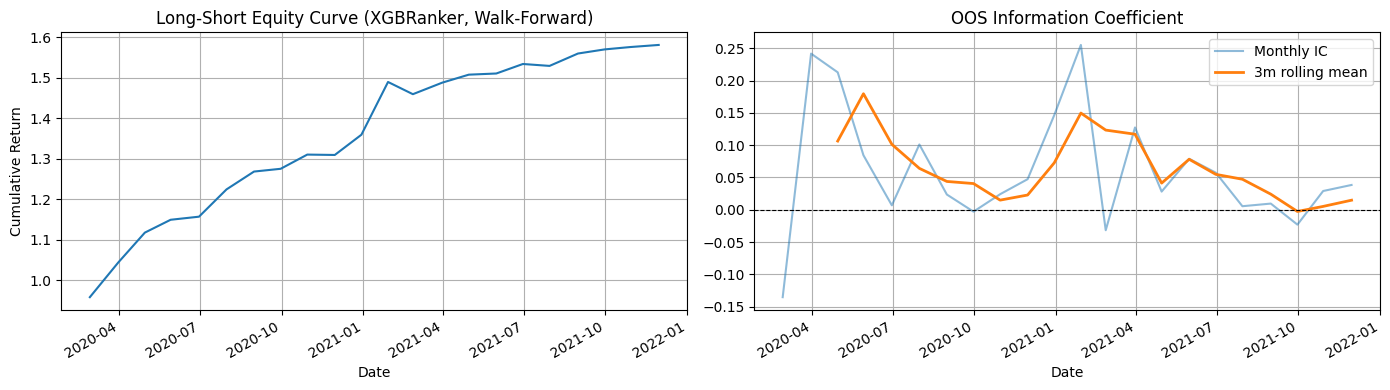

In [175]:
equity = (1 + portfolio).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

equity.plot(ax=axes[0], title="Long-Short Equity Curve (XGBRanker, Walk-Forward)")
axes[0].set_ylabel("Cumulative Return")
axes[0].grid(True)

monthly_ic.plot(ax=axes[1], alpha=0.5, label="Monthly IC")
monthly_ic.rolling(3).mean().plot(ax=axes[1], label="3m rolling mean", linewidth=2)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("OOS Information Coefficient")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

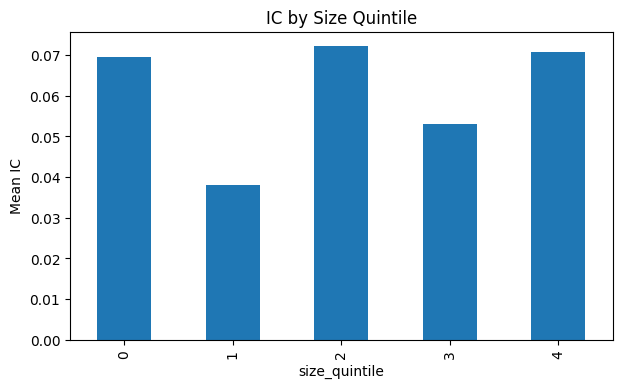

size_quintile
0    0.069584
1    0.038074
2    0.072175
3    0.053021
4    0.070741
dtype: float64


In [176]:
from scipy.stats import spearmanr

tmp = oos.copy()

tmp["size_quintile"] = (
    tmp.groupby("Date")["avg_dollar_vol_1m"]
       .transform(
           lambda x: pd.qcut(
               x.rank(method="first"),
               5,
               labels=False,
               duplicates="drop"
           )
       )
)

ic_size = (
    tmp.groupby(["Date", "size_quintile"])
       .apply(
           lambda x: spearmanr(
               x["score"],
               x["target_1m"]
           ).correlation,
           include_groups=False
       )
       .groupby(level=1)
       .mean()
)

ic_size.plot.bar(figsize=(7,4))
plt.ylabel("Mean IC")
plt.title("IC by Size Quintile")
plt.show()

print(ic_size)

In [177]:
# Top/bottom portfolio turnover

TOP_PCT = 0.10

dates = sorted(oos["Date"].unique())

top_sets = {}
bottom_sets = {}

for date in dates:

    df = oos[oos["Date"] == date].sort_values("score")

    n = max(1, int(len(df) * TOP_PCT))

    bottom_sets[date] = set(df.head(n)["SecuritiesCode"])
    top_sets[date] = set(df.tail(n)["SecuritiesCode"])


turnover = []

for i in range(1, len(dates)):

    prev_top = top_sets[dates[i-1]]
    curr_top = top_sets[dates[i]]

    prev_bottom = bottom_sets[dates[i-1]]
    curr_bottom = bottom_sets[dates[i]]

    top_turnover = 1 - len(prev_top & curr_top) / len(prev_top)
    bottom_turnover = 1 - len(prev_bottom & curr_bottom) / len(prev_bottom)

    turnover.append({
        "Date": dates[i],
        "Top": top_turnover,
        "Bottom": bottom_turnover,
        "Average": (top_turnover + bottom_turnover)/2
    })

turnover = pd.DataFrame(turnover)

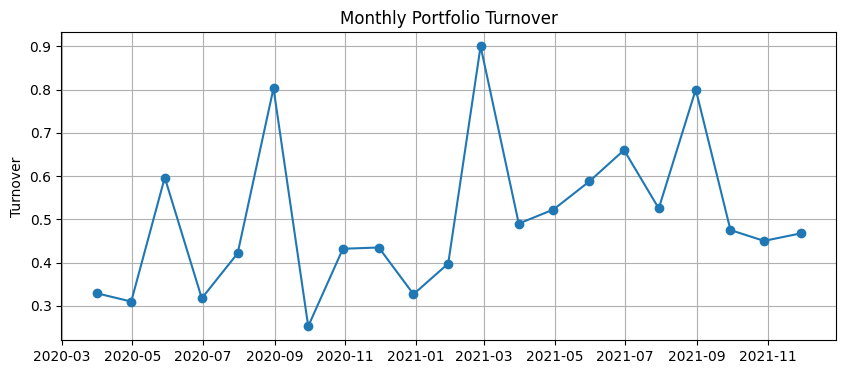

                             Date        Top     Bottom    Average
count                          21  21.000000  21.000000  21.000000
mean   2021-01-29 01:08:34.285714   0.448065   0.551691   0.499878
min           2020-03-31 00:00:00   0.206030   0.287879   0.252525
25%           2020-08-31 00:00:00   0.258883   0.447236   0.397500
50%           2021-01-29 00:00:00   0.395000   0.565000   0.467500
75%           2021-06-30 00:00:00   0.598985   0.606061   0.587500
max           2021-11-30 00:00:00   0.915000   0.885000   0.900000
std                           NaN   0.218892   0.151884   0.174005
Average turnover = 49.99%


In [178]:
plt.figure(figsize=(10,4))

plt.plot(turnover["Date"], turnover["Average"], marker="o")

plt.title("Monthly Portfolio Turnover")
plt.ylabel("Turnover")
plt.grid(True)

plt.show()

print(turnover.describe())
print(f"Average turnover = {turnover['Average'].mean():.2%}")

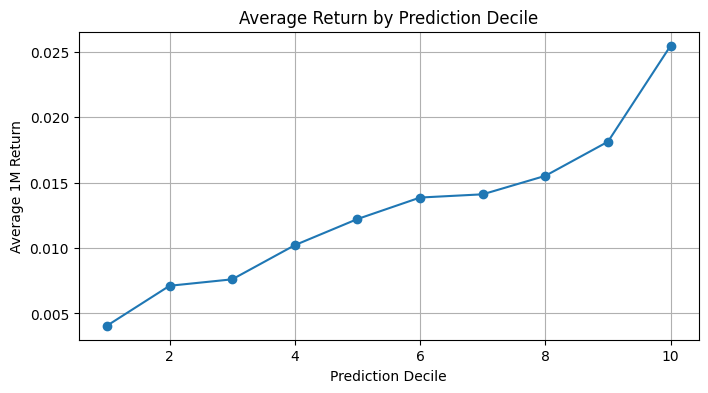

decile
0    0.004062
1    0.007117
2    0.007610
3    0.010223
4    0.012221
5    0.013864
6    0.014111
7    0.015525
8    0.018137
9    0.025474
Name: target_1m, dtype: float64


In [179]:
tmp = oos.copy()

tmp["decile"] = (
    tmp.groupby("Date")["score"]
       .transform(lambda x: pd.qcut(
           x.rank(method="first"),
           10,
           labels=False,
           duplicates="drop"
       ))
)

decile_returns = (
    tmp.groupby("decile")["target_1m"]
       .mean()
)

plt.figure(figsize=(8,4))

plt.plot(
    decile_returns.index + 1,
    decile_returns.values,
    marker="o"
)

plt.grid(True)

plt.xlabel("Prediction Decile")
plt.ylabel("Average 1M Return")
plt.title("Average Return by Prediction Decile")

plt.show()

print(decile_returns)

In [180]:
top = (
    oos.groupby("Date")
       .apply(
           lambda x: x.nlargest(
               max(1,int(len(x)*0.1)),
               "score"
           ),
           include_groups=False
       )
)

bottom = (
    oos.groupby("Date")
       .apply(
           lambda x: x.nsmallest(
               max(1,int(len(x)*0.1)),
               "score"
           ),
           include_groups=False
       )
)

comparison = pd.DataFrame({

    "Top": top[feature_cols].mean(),

    "Bottom": bottom[feature_cols].mean()

})

comparison["Difference"] = (
    comparison["Top"] -
    comparison["Bottom"]
)

comparison = comparison.reindex(

    comparison["Difference"]
    .abs()
    .sort_values(ascending=False)
    .index

)

comparison.head(30)

,Top,Bottom,Difference
q_OperatingProfit,-0.460710,0.580595,-1.041305
q_Profit,-0.453224,0.586439,-1.039663
Equity,-0.435078,0.591482,-1.026560
Profit,-0.395130,0.571608,-0.966738
log_market_cap,-0.638944,0.293155,-0.932099
q_OrdinaryProfit_ttm,-0.424083,0.492358,-0.916441
q_Profit_ttm,-0.405121,0.450947,-0.856068
ma_12m_ratio,-0.376965,0.449738,-0.826703
q_OperatingProfit_ttm,-0.405407,0.416202,-0.821609
earnings_yield,-0.364355,0.377458,-0.741813


C:\Users\naksh\AppData\Local\Temp\ipykernel_8728\1418432314.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearmanr(


Top Positive Factors
vol_12m                      0.026647
ttm_operating_roa            0.013782
max_return_3m                0.011758
ttm_operating_margin         0.009885
vol_6m                       0.008989
earnings_yield               0.008946
vol_3m                       0.008335
ttm_sales_to_equity          0.006943
forecast_roe                 0.006776
forecast_roa                 0.006740
ttm_roa                      0.006690
ttm_profit_to_assets         0.006690
ttm_operating_roe            0.006609
Equity_yoy                   0.006282
forecast_operating_margin    0.004432
TotalAssets_yoy              0.003392
ttm_roe                      0.003201
ttm_asset_turnover           0.003122
mom_6m                       0.002590
ttm_ordinary_margin          0.002387
dtype: float64

Top Negative Factors
ma_3m_ratio                  -0.041572
vol_1m                       -0.030234
mom_12m                      -0.028920
mom_1m                       -0.027615
ttm_roe_change_4q         

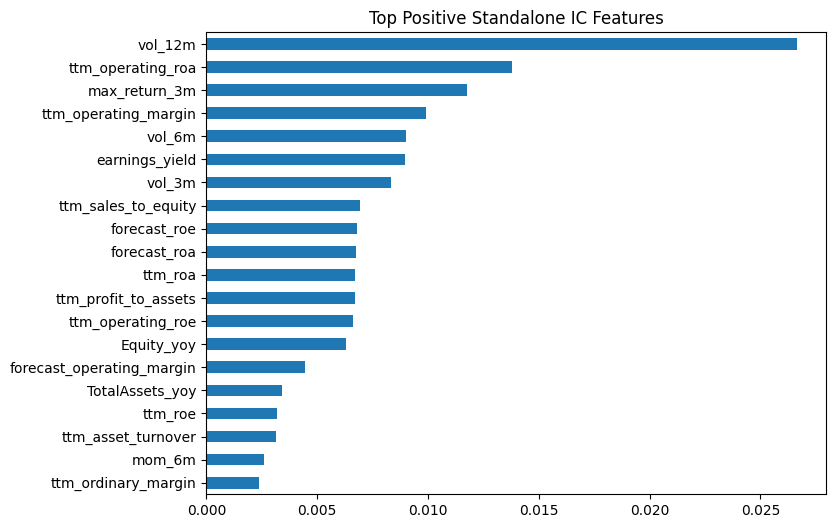

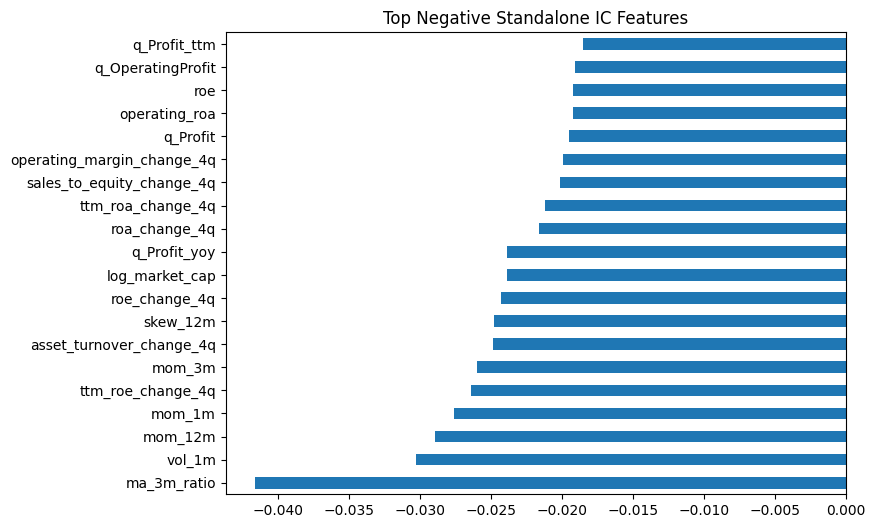

In [181]:
from scipy.stats import spearmanr

feature_ic = {}

for feature in feature_cols:

    ic = (
        oos.groupby("Date")
           .apply(
               lambda x:
               spearmanr(
                   x[feature],
                   x["target_1m"]
               ).correlation,
               include_groups=False
           )
    )

    feature_ic[feature] = ic.mean()

feature_ic = pd.Series(feature_ic)

print("Top Positive Factors")
print(feature_ic.sort_values(ascending=False).head(20))

print("\nTop Negative Factors")
print(feature_ic.sort_values().head(20))

plt.figure(figsize=(8,6))
feature_ic.sort_values(ascending=False).head(20).sort_values().plot.barh()
plt.title("Top Positive Standalone IC Features")
plt.show()

plt.figure(figsize=(8,6))
feature_ic.sort_values().head(20).plot.barh()
plt.title("Top Negative Standalone IC Features")
plt.show()

In [182]:
from scipy.stats import spearmanr

tmp = oos.copy()

tmp["size_quintile"] = (
    tmp.groupby("Date")["avg_dollar_vol_1m"]
       .transform(
           lambda x: pd.qcut(
               x.rank(method="first"),
               5,
               labels=False,
               duplicates="drop"
           )
       )
)

In [183]:
results = []

for feature in feature_cols:

    for q in range(5):

        subset = tmp[tmp["size_quintile"] == q]

        ic = (
            subset.groupby("Date")
                  .apply(
                      lambda x: spearmanr(
                          x[feature],
                          x["target_1m"]
                      ).correlation,
                      include_groups=False
                  )
        )

        results.append({

            "Feature": feature,
            "Quintile": q,
            "Mean IC": ic.mean()

        })

feature_ic_size = pd.DataFrame(results)

C:\Users\naksh\AppData\Local\Temp\ipykernel_8728\1796347310.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  lambda x: spearmanr(


In [184]:
pivot = feature_ic_size.pivot(
    index="Feature",
    columns="Quintile",
    values="Mean IC"
)

pivot.columns = [
    "Small",
    "Q2",
    "Q3",
    "Q4",
    "Large"
]

pivot.head()

,Small,Q2,Q3,Q4,Large
Feature,,,,,
AdjustmentFactor,NaN,NaN,NaN,NaN,NaN
EarningsPerShare,-0.004089,-0.007152,-0.005798,-0.001053,0.024305
Equity,-0.048578,-0.021570,-0.008522,0.001996,-0.000711
Equity_yoy,0.016359,0.020101,0.002412,0.002879,-0.001956
NetSales,-0.007467,-0.005177,0.002449,0.002503,0.004233


In [185]:
pivot.sort_values(
    "Small",
    ascending=False
).head(25)

,Small,Q2,Q3,Q4,Large
Feature,,,,,
vol_12m,0.044938,-0.011234,0.033419,0.016220,0.083887
vol_6m,0.032724,0.000735,0.020893,0.003439,0.027927
vol_3m,0.027610,0.008735,0.026465,-0.001321,0.017666
forecast_roe,0.022474,0.008089,-0.003522,0.004098,0.012224
ttm_asset_turnover,0.022146,0.010912,-0.002706,-0.008173,0.011588
earnings_yield,0.021972,-0.004311,-0.001402,0.005681,0.008682
max_return_3m,0.018222,0.013432,0.022393,0.003735,0.023289
TotalAssets_yoy,0.016682,0.011154,-0.004779,0.012904,-0.010369
asset_turnover,0.016529,-0.004641,-0.019759,-0.032189,0.001286


In [186]:
pivot.sort_values(
    "Large",
    ascending=False
).head(25)

,Small,Q2,Q3,Q4,Large
Feature,,,,,
vol_12m,0.044938,-0.011234,0.033419,0.016220,0.083887
equity_ratio,-0.012157,0.015154,-0.011179,-0.006467,0.029954
vol_6m,0.032724,0.000735,0.020893,0.003439,0.027927
forecast_roa,0.009856,0.014323,-0.009654,0.002356,0.024538
EarningsPerShare,-0.004089,-0.007152,-0.005798,-0.001053,0.024305
max_return_3m,0.018222,0.013432,0.022393,0.003735,0.023289
ttm_roa,-0.020213,0.001746,0.000010,0.003424,0.022733
ttm_profit_to_assets,-0.020213,0.001746,0.000010,0.003424,0.022733
forecast_profit_margin,-0.007829,0.000293,-0.014190,0.004958,0.022729


In [187]:
pivot["Difference"] = pivot["Small"] - pivot["Large"]

pivot.sort_values(
    "Difference",
    ascending=False
).head(30)

,Small,Q2,Q3,Q4,Large,Difference
Feature,,,,,,
q_NetSales_yoy,-0.001240,-0.017745,-0.014888,-0.039836,-0.042663,0.041423
asset_turnover_change_4q,0.002726,-0.035609,-0.025216,-0.032422,-0.038612,0.041337
sales_to_equity_change_4q,-0.009237,-0.031191,-0.023746,-0.033446,-0.046468,0.037231
sales_to_equity,0.014021,0.000062,-0.005600,-0.018697,-0.013601,0.027623
TotalAssets_yoy,0.016682,0.011154,-0.004779,0.012904,-0.010369,0.027052
roe_change_4q,0.001062,-0.027744,-0.037218,-0.038150,-0.024348,0.025410
operating_margin_change_4q,-0.003444,-0.014823,-0.026630,-0.013633,-0.028503,0.025059
vol_1m,-0.007892,-0.024962,-0.010004,-0.033872,-0.032699,0.024807
roa_change_4q,0.000763,-0.027042,-0.031380,-0.031997,-0.022192,0.022955


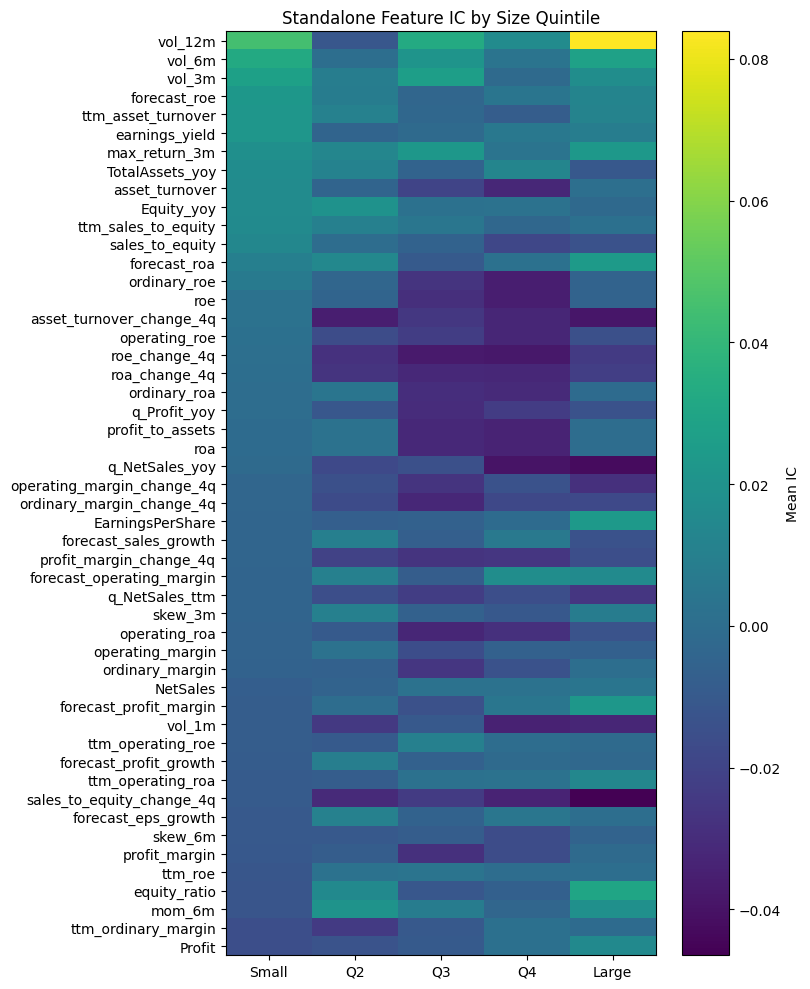

In [188]:
import matplotlib.pyplot as plt

plot_data = (
    pivot.drop(columns="Difference")
         .sort_values("Small", ascending=False)
         .head(50)
)

plt.figure(figsize=(8,10))

plt.imshow(
    plot_data.values,
    aspect="auto"
)

plt.xticks(
    range(5),
    plot_data.columns
)

plt.yticks(
    range(len(plot_data)),
    plot_data.index
)

plt.colorbar(label="Mean IC")

plt.title("Standalone Feature IC by Size Quintile")

plt.tight_layout()

plt.show()

c:\Users\naksh\Projects\xgboost_stock_ranking\.venv\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\naksh\AppData\Local\Temp\ipykernel_8728\4049917978.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


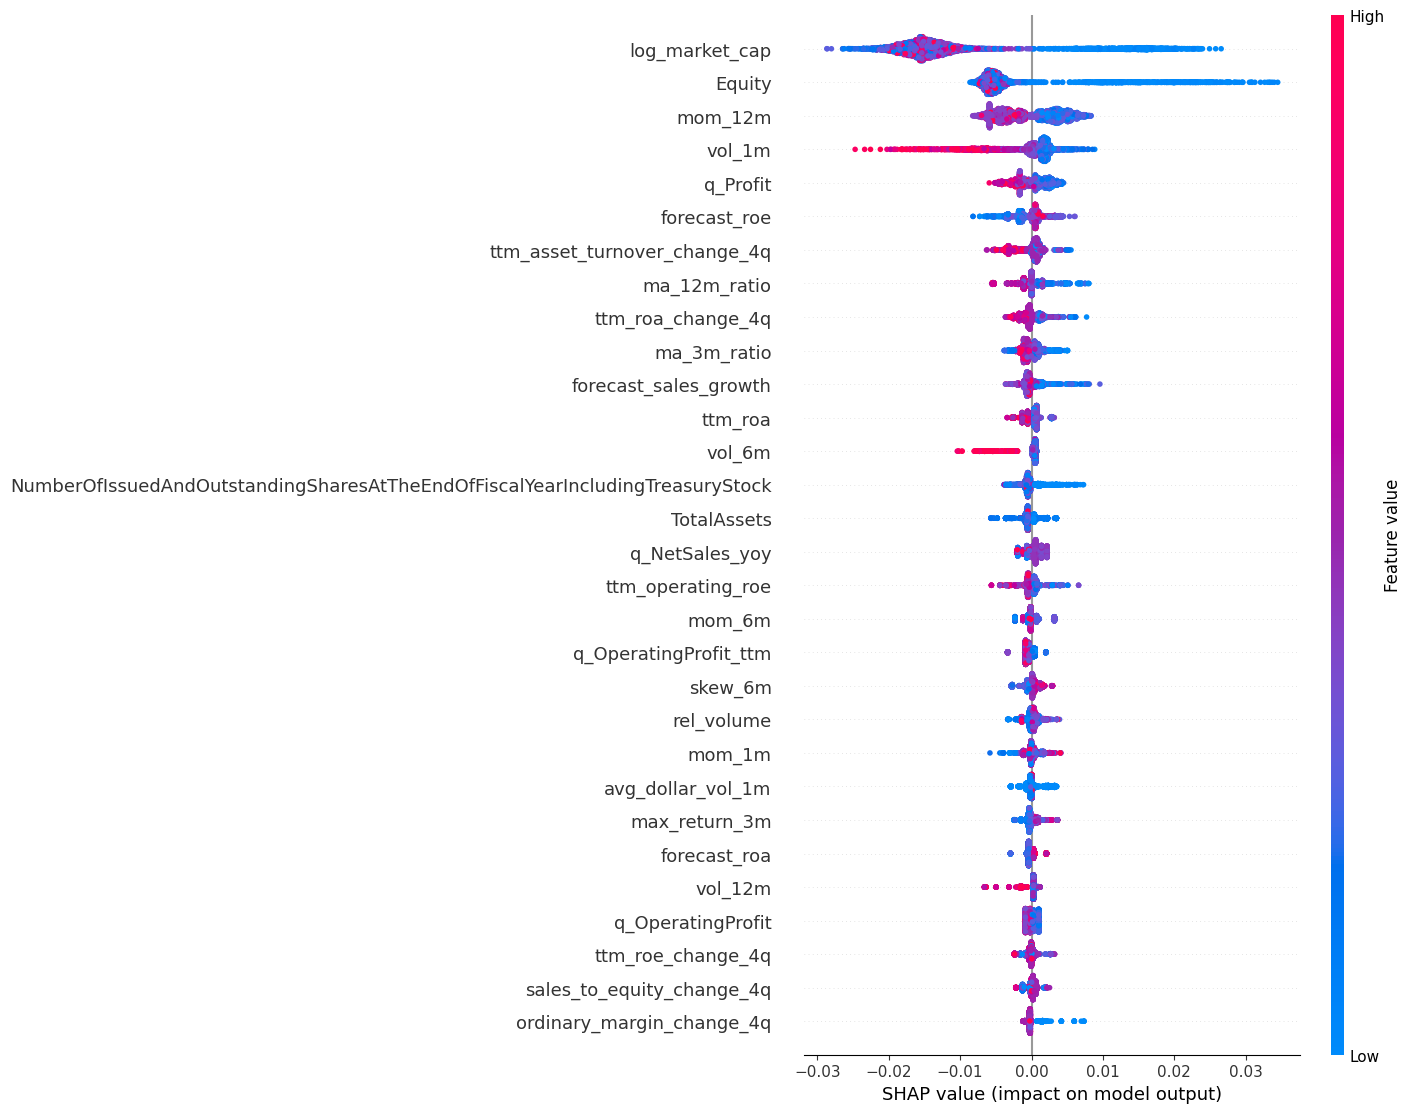

In [189]:
import shap
import matplotlib.pyplot as plt

# Sample to make SHAP faster
sample = train_df[feature_cols].sample(
    min(5000, len(train_df)),
    random_state=42
)

explainer = shap.TreeExplainer(ranker)
shap_values = explainer.shap_values(sample)

plt.figure(figsize=(10,10))

shap.summary_plot(
    shap_values,
    sample,
    max_display=30,
    show=False
)

plt.tight_layout()
plt.show()

In [190]:
gain = pd.DataFrame({

    "feature":feature_cols,

    "gain":ranker.feature_importances_

})

gain = gain.sort_values(
    "gain",
    ascending=False
)

display(gain.head(30))

,feature,gain
76,log_market_cap,0.132487
4,Equity,0.041169
34,q_OrdinaryProfit_ttm,0.023904
42,ttm_ordinary_margin,0.017864
26,forecast_profit_growth,0.017572
33,q_OperatingProfit_ttm,0.017334
40,ttm_profit_margin,0.016892
66,vol_1m,0.016044
39,ttm_operating_roe,0.015285
1,NetSales,0.015134


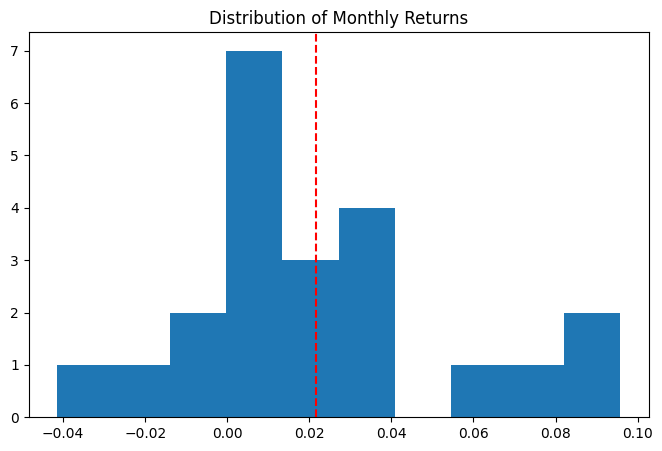

In [191]:
plt.figure(figsize=(8,5))

plt.hist(portfolio, bins=10)

plt.axvline(portfolio.mean(), color="red", linestyle="--")

plt.title("Distribution of Monthly Returns")

plt.show()

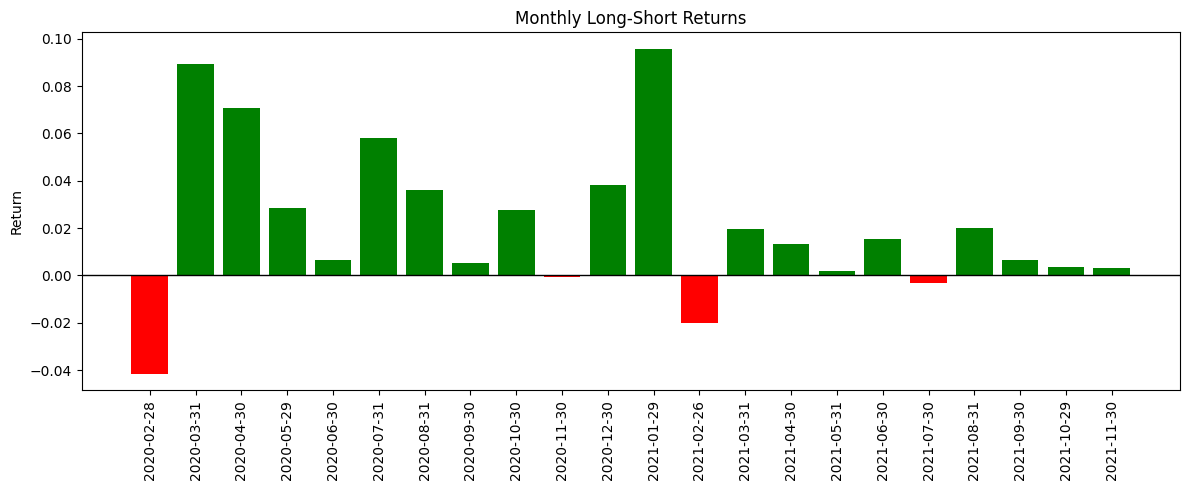

In [192]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

colors = ["green" if x > 0 else "red" for x in portfolio]

plt.bar(portfolio.index.astype(str), portfolio.values, color=colors)

plt.axhline(0, color="black", linewidth=1)

plt.xticks(rotation=90)

plt.title("Monthly Long-Short Returns")
plt.ylabel("Return")

plt.tight_layout()
plt.show()